# ICB Response Analysis v4
## Harmonized analysis of ICB clinical response in LUAD across 6 datasets

**Datasets**: Shim 2020, Ravi 2023, MSK 2018, MSK MIND 2020, MSK 2017, Cho 2020

**Aim**: Harmonize clinical variables from seven public ICB-treated LUAD cohorts, analyze response patterns by age group, perform age-cutoff sensitivity analysis, and model predictors of ICB response using multiple model formulations.

## Setup & Data Loading

In [1]:
# ============================================================
# Setup
# ============================================================
library("tidyverse")
library("broom")

figures <- "/public/home/liwang/project/lung_cancer_ST/scRNA_data/young_lung_cancer_collection/analysis_health_tumor_v6/figures"
obj     <- "/public/home/liwang/project/lung_cancer_ST/scRNA_data/young_lung_cancer_collection/analysis_health_tumor_v6/objects"
icb_dir <- file.path(obj, "ICB_Clinical_Response")

dir.create(file.path(figures, "Figures_raw"), showWarnings = FALSE, recursive = TRUE)

message("Setup complete. figures: ", figures)
message("obj: ", obj)
message("ICB dir: ", icb_dir)

── Attaching packages ────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 1.3.1 ──



✔ ggplot2 3.4.4     ✔ purrr   1.0.1
✔ tibble  3.2.1     ✔ dplyr   1.1.2
✔ tidyr   1.3.0     ✔ stringr 1.5.0
✔ readr   2.1.4     ✔ forcats 1.0.0



── Conflicts ───────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()



Setup complete. figures: /public/home/liwang/project/lung_cancer_ST/scRNA_data/young_lung_cancer_collection/analysis_health_tumor_v2/figures



obj: /public/home/liwang/project/lung_cancer_ST/scRNA_data/young_lung_cancer_collection/analysis_health_tumor_v2/objects



ICB dir: /public/home/liwang/project/lung_cancer_ST/scRNA_data/young_lung_cancer_collection/analysis_health_tumor_v2/objects/ICB_Clinical_Response



In [ ]:
# ============================================================
# Load all raw datasets and inspect
# ============================================================

# --- Shim 2020 (raw) ---
Shim_raw <- read_csv(
  file = file.path(icb_dir, "Shim-ICB-response-mmc2.csv"),
  skip = 2, n_max = 198, show_col_types = FALSE
)
message("Shim_raw: ", nrow(Shim_raw), " rows, ", ncol(Shim_raw), " cols")

# --- Ravi 2023 (raw) ---
Ravi_raw <- read_csv(
  file = file.path(icb_dir, "Ravi_NatureGenetics_2023_ICB_MOESM3.csv"),
  skip = 2, show_col_types = FALSE
)
message("Ravi_raw: ", nrow(Ravi_raw), " rows, ", ncol(Ravi_raw), " cols")

# --- MSK 2018 (patient + sample) ---
MSK18_raw <- read_tsv(
  file = file.path(icb_dir, "nsclc_pd1_msk_2018_data_clinical_patient.txt"),
  comment = "#", show_col_types = FALSE
)
MSK18_sample <- read_tsv(
  file = file.path(icb_dir, "nsclc_pd1_msk_2018_data_clinical_sample.txt"),
  comment = "#", show_col_types = FALSE
)
message("MSK2018: ", nrow(MSK18_raw), " patients, ", nrow(MSK18_sample), " samples")

# --- MSK MIND 2020 (patient + sample) ---
MSK20_raw <- read_tsv(
  file = file.path(icb_dir, "lung_msk_mind_2020_data_clinical_patient.txt"),
  comment = "#", show_col_types = FALSE
)
MSK20_sample <- read_tsv(
  file = file.path(icb_dir, "lung_msk_mind_2020_data_clinical_sample.txt"),
  comment = "#", show_col_types = FALSE
)
message("MSK2020: ", nrow(MSK20_raw), " patients, ", nrow(MSK20_sample), " samples")

# --- MSK 2017 (patient + sample) ---
MSK17_raw <- read_tsv(
  file = file.path(icb_dir, "lung_msk_2017_data_clinical_patient.txt"),
  comment = "#", show_col_types = FALSE
)
MSK17_sample <- read_tsv(
  file = file.path(icb_dir, "lung_msk_2017_data_clinical_sample.txt"),
  comment = "#", show_col_types = FALSE
)
message("MSK2017: ", nrow(MSK17_raw), " patients, ", nrow(MSK17_sample), " samples")

# --- Cho 2020 (parsed CSVs) ---
Cho_S2A <- read_csv(file.path(icb_dir, "cho_S2A_parsed.csv"), show_col_types = FALSE)
Cho_S2B <- read_csv(file.path(icb_dir, "cho_S2B_parsed.csv"), show_col_types = FALSE)
message("Cho S2A: ", nrow(Cho_S2A), " rows; S2B: ", nrow(Cho_S2B), " rows")

In [3]:
# ============================================================
# Inspect key columns in each dataset
# ============================================================

# --- Shim: LUAD counts ---
cat("=== Shim 2020: Histology ===\n")
print(table(Shim_raw$Histology, useNA="ifany"))
cat("\nShim colnames:\n")
print(colnames(Shim_raw))

# --- Ravi: LUAD counts ---
cat("\n=== Ravi 2023: Histology_Harmonized ===\n")
print(table(Ravi_raw$Histology_Harmonized, useNA="ifany"))

# --- MSK 2018: Oncotree LUAD counts ---
cat("\n=== MSK 2018 sample: Oncotree Code ===\n")
print(table(MSK18_sample$ONCOTREE_CODE, useNA="ifany"))
cat("\nMSK2018 patient colnames:\n")
print(colnames(MSK18_raw))
cat("\nMSK2018 sample colnames:\n")
print(colnames(MSK18_sample))

# --- MSK MIND 2020: Oncotree LUAD counts ---
cat("\n=== MSK 2020 sample: Oncotree Code ===\n")
print(table(MSK20_sample$ONCOTREE_CODE, useNA="ifany"))
cat("\nMSK2020 patient colnames:\n")
print(colnames(MSK20_raw))
cat("\nMSK2020 sample colnames (driver genes):\n")
print(colnames(MSK20_sample)[18:28])

# --- Cho 2020: already LUAD-only ---
cat("\n=== Cho S2A/S2B: colnames ===\n")
cat("S2A histology: ", unique(Cho_S2A$histology), "\n")
cat("S2B histology: ", unique(Cho_S2B$histology), "\n")

=== Shim 2020: Histology ===



                             LUAD                              LUSC 
                              129                                58 
OTHERS (Adenoid cystic carcinoma)                    OTHERS (LCNEC) 
                                1                                 5 
            OTHERS (PD carcinoma)    OTHERS (Pleomorphic carcinoma) 
                                1                                 4 



Shim colnames:


 [1] "Patient ID"                       "Age (yrs)"                       
 [3] "ECOG performance status"          "Sex (M=male, F=female)"          
 [5] "Response"                         "Histology"                       
 [7] "Smoking Status (cigarettes only)" "Smoking pack years"              
 [9] "Actionable mutations"             "Treatment"                       
[11] "Line of therapy"                  "Radio therapy"                   
[13] "HR deficiency"                    "% PD-L1 expression"              
[15] "TMB"                              "HLA-corrected TMB"               
[17] "Predicted neoantigen burden"      "PFS  (0=censor, 1=event)"        
[19] "PFS (months)"                     "Death (0=censor, 1=event)"       
[21] "OS (months)"                      "HLA status"                      
[23] "HLA A1 allele"                    "HLA A2 allele"                   
[25] "HLA B1 allele"                    "HLA B2 allele"                   
[27] "HLA C1 allele"     


=== Ravi 2023: Histology_Harmonized ===


...


MSK2020 sample colnames (driver genes):


 [1] "AGE_AT_SEQ_REPORTED_YEARS" "MGMT_STATUS"              
 [3] "EGFR_DRIVER"               "ALK_DRIVER"               
 [5] "ERBB2_DRIVER"              "ROS1_DRIVER"              
 [7] "RET_DRIVER"                "BRAF_DRIVER"              
 [9] "MET_DRIVER"                "STK11_DRIVER"             
[11] "ARID1A_DRIVER"            



=== Cho S2A/S2B: colnames ===


S2A histology:  LUAD 


S2B histology:  LUAD SCC 


## Data Harmonization

In [ ]:
# ============================================================
# Harmonize Shim 2020 (LUAD only)
# ============================================================
Shim <- Shim_raw %>%
  filter(Histology == "LUAD") %>%
  transmute(
    patient_id       = `Patient ID`,
    age_yrs          = as.numeric(`Age (yrs)`),
    gender           = `Sex (M=male, F=female)`,
    histology        = "LUAD",
    smoking_status   = `Smoking Status (cigarettes only)`,
    smoking_pack_yrs = as.numeric(`Smoking pack years`),
    line_of_therapy  = case_when(
      `Line of therapy` == "First"         ~ "1",
      `Line of therapy` == "Second"        ~ "2",
      `Line of therapy` == "Third or more" ~ "3+",
      TRUE ~ NA_character_
    ),
    pdl1_pct = pmin(as.numeric(`% PD-L1 expression`), 100),
    oncogenic_driver_raw = `Actionable mutations`,
    oncogenic_driver = case_when(
      is.na(`Actionable mutations`) | `Actionable mutations` == "" ~ "None",
      TRUE ~ str_extract(`Actionable mutations`, "^[A-Z0-9]+")
    ),
    oncogenic_driver = ifelse(oncogenic_driver == "HER2", "ERBB2", oncogenic_driver),
    icb_agent = Treatment,
    response_raw = Response,
    response_NR = case_when(
      Response %in% c("PD", "SD") ~ "N",
      Response %in% c("PR", "CR") ~ "R",
      TRUE ~ NA_character_
    ),
    pfs_event = `PFS  (0=censor, 1=event)`,
    pfs_days  = round(as.numeric(`PFS (months)`) * 30),
    os_event  = `Death (0=censor, 1=event)`,
    os_days   = round(as.numeric(`OS (months)`) * 30),
    dataset   = "Shim_AO_2020",
    study     = "Shim_AO_2020"
  )
message("Shim LUAD: ", nrow(Shim), " patients")

# ============================================================
# Harmonize Ravi 2023 (Adeno = LUAD only)
# ============================================================
Ravi <- Ravi_raw %>%
  filter(Histology_Harmonized == "Adeno") %>%
  filter(Harmonized_Confirmed_BOR %in% c("PD", "SD", "PR", "CR")) %>%
  transmute(
    patient_id       = Harmonized_SU2C_Participant_ID_v2,
    age_yrs          = as.numeric(Patient_Age_at_Diagnosis),
    gender           = case_when(
      Patient_Sex == "M" ~ "M",
      Patient_Sex == "F" ~ "F",
      TRUE ~ NA_character_
    ),
    histology        = "LUAD",
    smoking_status   = case_when(
      Patient_Smoking_Status == "0" ~ "Never",
      Patient_Smoking_Status == "1" ~ "Former",
      Patient_Smoking_Status == "2" ~ "Current",
      TRUE ~ NA_character_
    ),
    smoking_pack_yrs = as.numeric(Patient_Smoking_Pack_Years_Harmonized),
    line_of_therapy  = case_when(
      Line_of_Therapy == "1" ~ "1",
      Line_of_Therapy == "2" ~ "2",
      Line_of_Therapy %in% c("3", "4", "5", "6", "7", "8") ~ "3+",
      TRUE ~ NA_character_
    ),
    pdl1_pct = pmin(as.numeric(PDL1_TPS) * 100, 100),  # PDL1_TPS is 0-1 proportion
    oncogenic_driver_raw = Clinical_Driver,
    oncogenic_driver = case_when(
      is.na(Clinical_Driver) | Clinical_Driver == "" ~ "None",
      Clinical_Driver == "None" ~ "None",
      TRUE ~ str_extract(Clinical_Driver, "^[A-Z0-9]+")
    ),
    oncogenic_driver = ifelse(oncogenic_driver == "HER2", "ERBB2", oncogenic_driver),
    icb_agent = Agent_PD1,
    response_raw = Harmonized_Confirmed_BOR,
    response_NR = case_when(
      Harmonized_Confirmed_BOR %in% c("PD", "SD") ~ "N",
      Harmonized_Confirmed_BOR %in% c("PR", "CR") ~ "R",
      TRUE ~ NA_character_
    ),
    pfs_event = as.numeric(Harmonized_PFS_Event),
    pfs_days  = round(as.numeric(Harmonized_PFS_Days)),
    os_event  = as.numeric(Harmonized_OS_Event),
    os_days   = round(as.numeric(Harmonized_OS_Days)),
    dataset   = "Ravi_NG_2023",
    study     = "Ravi_NG_2023"
  )
message("Ravi LUAD: ", nrow(Ravi), " patients")

In [11]:
# ============================================================
# Harmonize MSK MIND 2020
# Filter LUAD via sample file Oncotree, extract driver genes + PD-L1
# ============================================================

# Get LUAD patient IDs from sample file (Oncotree)
MSK20_luad_pids <- MSK20_sample %>%
  filter(ONCOTREE_CODE == "LUAD") %>%
  pull(PATIENT_ID) %>%
  unique()
message("MSK2020 LUAD patients (by Oncotree): ", length(MSK20_luad_pids))

# Aggregate sample-level data per patient: driver genes + PD-L1
# Note: read_tsv converts spaces to underscores, TRUE/FALSE for driver columns
MSK20_sample_agg <- MSK20_sample %>%
  filter(PATIENT_ID %in% MSK20_luad_pids) %>%
  group_by(PATIENT_ID) %>%
  summarise(
    pdl1_pct_sample = first(na.omit(CLINICAL_PDL1_SCORE)),
    EGFR_driver  = ifelse(any(EGFR_DRIVER == TRUE, na.rm = TRUE),  "EGFR", NA_character_),
    ALK_driver   = ifelse(any(ALK_DRIVER == TRUE, na.rm = TRUE),   "ALK", NA_character_),
    ERBB2_driver = ifelse(any(ERBB2_DRIVER == TRUE, na.rm = TRUE), "ERBB2", NA_character_),
    ROS1_driver  = ifelse(any(ROS1_DRIVER == TRUE, na.rm = TRUE),  "ROS1", NA_character_),
    RET_driver   = ifelse(any(RET_DRIVER == TRUE, na.rm = TRUE),   "RET", NA_character_),
    BRAF_driver  = ifelse(any(BRAF_DRIVER == TRUE, na.rm = TRUE),  "BRAF", NA_character_),
    MET_driver   = ifelse(any(MET_DRIVER == TRUE, na.rm = TRUE),   "MET", NA_character_),
    STK11_driver = ifelse(any(STK11_DRIVER == TRUE, na.rm = TRUE), "STK11", NA_character_),
    .groups = "drop"
  ) %>%
  mutate(
    oncogenic_driver_sample = case_when(
      !is.na(EGFR_driver)  ~ "EGFR",
      !is.na(BRAF_driver)  ~ "BRAF",
      !is.na(ALK_driver)   ~ "ALK",
      !is.na(ERBB2_driver) ~ "ERBB2",
      !is.na(ROS1_driver)  ~ "ROS1",
      !is.na(RET_driver)   ~ "RET",
      !is.na(MET_driver)   ~ "MET",
      !is.na(STK11_driver) ~ "STK11",
      TRUE ~ "None"
    )
  )

message("MSK2020 sample-level aggregation: ", nrow(MSK20_sample_agg), " patients")

# Harmonize patient-level data
MSK20 <- MSK20_raw %>%
  filter(PATIENT_ID %in% MSK20_luad_pids) %>%
  left_join(MSK20_sample_agg, by = "PATIENT_ID") %>%
  transmute(
    patient_id       = PATIENT_ID,
    age_yrs          = as.numeric(AGE),
    gender           = case_when(
      SEX == "Male"   ~ "M",
      SEX == "Female" ~ "F",
      TRUE ~ NA_character_
    ),
    histology        = "LUAD",
    smoking_status   = case_when(
      SMOKING_STATUS == "Never smoker" ~ "Never",
      SMOKING_STATUS == "Former smoker" ~ "Former",
      grepl("Current", SMOKING_STATUS) ~ "Current",
      TRUE ~ NA_character_
    ),
    smoking_pack_yrs = as.numeric(PACK_YEARS),
    line_of_therapy  = case_when(
      TX_SETTING == "1" ~ "1",
      TX_SETTING == "2" ~ "2",
      TX_SETTING %in% c("3", "4", "5", "6", "7") ~ "3+",
      TRUE ~ NA_character_
    ),
    pdl1_pct = as.numeric(pdl1_pct_sample),
    oncogenic_driver_raw = oncogenic_driver_sample,
    oncogenic_driver = oncogenic_driver_sample,
    icb_agent = IO_DRUG,
    response_raw = BOR,
    response_NR = case_when(
      BOR %in% c("POD", "POD/death", "POD/brain", "POD/clinical", "POD/bone") ~ "N",
      BOR %in% c("SD") ~ "N",
      BOR %in% c("PR", "CR") ~ "R",
      TRUE ~ NA_character_
    ),
    pfs_event = case_when(
      PFS_STATUS == "0:CENSORED"  ~ 0,
      PFS_STATUS == "1:PROGRESS"  ~ 1,
      TRUE ~ NA_real_
    ),
    pfs_days  = round(as.numeric(PFS_MONTHS) * 30),
    os_event  = case_when(
      VITAL_STATUS == "No"  ~ 0,
      VITAL_STATUS == "Yes" ~ 1,
      TRUE ~ NA_real_
    ),
    os_days   = round(as.numeric(OS_INT) * 30),
    dataset   = "MSK_MIND_2020",
    study     = "MSK_MIND_2020"
  )

message("MSK2020 LUAD harmonized: ", nrow(MSK20), " patients")
cat("\nMSK2020 BOR → response_NR mapping:\n")
print(table(MSK20$response_raw, MSK20$response_NR, useNA = "ifany"))
cat("\nMSK2020 driver gene distribution:\n")
print(table(MSK20$oncogenic_driver, useNA = "ifany"))

MSK2020 LUAD patients (by Oncotree): 180



MSK2020 sample-level aggregation: 180 patients



Warning message:
“There was 1 warning in `transmute()`.
ℹ In argument: `smoking_pack_yrs = as.numeric(PACK_YEARS)`.
Caused by warning:
! 强制改变过程中产生了NA”


MSK2020 LUAD harmonized: 180 patients




MSK2020 BOR → response_NR mapping:


              
                N  R
  CR            0  5
  POD          71  0
  POD/bone      2  0
  POD/brain     7  0
  POD/clinical  1  0
  POD/death    21  0
  PR            0 34
  SD           39  0



MSK2020 driver gene distribution:



 BRAF  EGFR ERBB2   MET  None STK11 
    4    20    16     6    99    35 


In [12]:
# ============================================================
# Harmonize MSK 2018
# Filter LUAD via sample file Oncotree, use DCB as response proxy
# DCB: YES → R, NO → N, NE → NA
# ============================================================

# Get LUAD patient IDs from sample file
MSK18_luad_pids <- MSK18_sample %>%
  filter(ONCOTREE_CODE == "LUAD") %>%
  pull(PATIENT_ID) %>%
  unique()
message("MSK2018 LUAD patients (by Oncotree): ", length(MSK18_luad_pids))

# Aggregate sample-level PD-L1 per patient
MSK18_sample_agg <- MSK18_sample %>%
  filter(PATIENT_ID %in% MSK18_luad_pids) %>%
  group_by(PATIENT_ID) %>%
  summarise(
    pdl1_pct_sample = first(na.omit(PDL1_SCORE)),
    .groups = "drop"
  )
message("MSK2018 sample aggregation: ", nrow(MSK18_sample_agg), " patients")

# Harmonize
MSK18 <- MSK18_raw %>%
  filter(PATIENT_ID %in% MSK18_luad_pids) %>%
  left_join(MSK18_sample_agg, by = "PATIENT_ID") %>%
  transmute(
    patient_id       = PATIENT_ID,
    age_yrs          = as.numeric(AGE),
    gender           = case_when(
      SEX == "Male"   ~ "M",
      SEX == "Female" ~ "F",
      TRUE ~ NA_character_
    ),
    histology        = "LUAD",
    smoking_status   = case_when(
      SMOKER == "Never" ~ "Never",
      SMOKER == "Ever"  ~ "Former",   # cannot distinguish Former vs Current
      TRUE ~ NA_character_
    ),
    smoking_pack_yrs = NA_real_,       # not available in MSK 2018
    line_of_therapy  = case_when(
      LINES_OF_TX == "1" ~ "1",
      LINES_OF_TX == "2" ~ "2",
      TRUE ~ "3+"
    ),
    pdl1_pct = as.numeric(pdl1_pct_sample),
    oncogenic_driver_raw = NA_character_,
    oncogenic_driver = "None",         # not available in MSK 2018
    icb_agent = TREATMENT_TYPE,
    response_raw = DURABLE_CLINICAL_BENEFIT,
    response_NR = case_when(
      DURABLE_CLINICAL_BENEFIT == "YES" ~ "R",
      DURABLE_CLINICAL_BENEFIT == "NO"  ~ "N",
      TRUE ~ NA_character_
    ),
    pfs_event = case_when(
      PFS_STATUS == "0:Not Progressed" ~ 0,
      PFS_STATUS == "1:Progressed"     ~ 1,
      TRUE ~ NA_real_
    ),
    pfs_days  = round(as.numeric(PFS_MONTHS) * 30),
    os_event  = NA_real_,              # not available
    os_days   = NA_real_,              # not available
    dataset   = "MSK_2018",
    study     = "MSK_2018"
  )

message("MSK2018 LUAD harmonized: ", nrow(MSK18), " patients")
cat("\nMSK2018 DCB → response_NR mapping:\n")
print(table(MSK18$response_raw, MSK18$response_NR, useNA = "ifany"))

MSK2018 LUAD patients (by Oncotree): 186



MSK2018 sample aggregation: 186 patients



MSK2018 LUAD harmonized: 186 patients




MSK2018 DCB → response_NR mapping:


     
        N   R <NA>
  NE    0   0    7
  NO  124   0    0
  YES   0  55    0


In [13]:
# ============================================================
# Harmonize Cho 2020
# S2A: Discovery (9 LUAD), S2B: Validation (39 LUAD, exclude SCC)
# Missing: smoking, line_of_therapy, oncogenic_driver → NA
# ============================================================

# S2A (Discovery) - already LUAD-only
Cho_S2A_clean <- Cho_S2A %>%
  transmute(
    patient_id       = patient_id,
    age_yrs          = as.numeric(age_yrs),
    gender           = gender,
    histology        = "LUAD",
    smoking_status   = NA_character_,
    smoking_pack_yrs = NA_real_,
    line_of_therapy  = NA_character_,
    pdl1_pct         = NA_real_,  # S2A only has pdl1_status (Yes/No), not percentage
    oncogenic_driver_raw = NA_character_,
    oncogenic_driver = "None",
    icb_agent        = icb_agent,
    response_raw     = bor,
    response_NR      = response_NR,
    pfs_event        = NA_real_,
    pfs_days         = round(as.numeric(pfs_months) * 30),
    os_event         = NA_real_,
    os_days          = round(as.numeric(os_months) * 30),
    dataset          = "Cho_EMM_2020_Discovery",
    study            = "Cho_EMM_2020"
  )
message("Cho S2A (Discovery): ", nrow(Cho_S2A_clean), " LUAD patients")

# S2B (Validation) - filter LUAD, exclude SCC
Cho_S2B_clean <- Cho_S2B %>%
  filter(histology == "LUAD") %>%
  transmute(
    patient_id       = patient_id,
    age_yrs          = as.numeric(age_yrs),
    gender           = gender,
    histology        = "LUAD",
    smoking_status   = NA_character_,
    smoking_pack_yrs = NA_real_,
    line_of_therapy  = NA_character_,
    pdl1_pct         = as.numeric(pdl1_pct),
    oncogenic_driver_raw = NA_character_,
    oncogenic_driver = "None",
    icb_agent        = icb_agent,
    response_raw     = bor,
    response_NR      = response_NR,
    pfs_event        = NA_real_,
    pfs_days         = round(as.numeric(pfs_months) * 30),
    os_event         = NA_real_,
    os_days          = round(as.numeric(os_months) * 30),
    dataset          = "Cho_EMM_2020_Validation",
    study            = "Cho_EMM_2020"
  )
message("Cho S2B (Validation): ", nrow(Cho_S2B_clean), " LUAD patients")

cat("\nCho S2A response:\n")
print(table(Cho_S2A_clean$response_NR))
cat("\nCho S2B response:\n")
print(table(Cho_S2B_clean$response_NR))

Cho S2A (Discovery): 9 LUAD patients



Cho S2B (Validation): 39 LUAD patients




Cho S2A response:



N R 
6 3 



Cho S2B response:



 N  R 
25 14 


In [ ]:
# ============================================================
# Harmonize MSK 2017 (unique patients not in MSK 2018)
# DCB: YES → R, NO → N; NA/await/NE → NA
# Note: read_tsv converts spaces to underscores in column names
# ============================================================

# Filter ICB-treated LUAD
MSK17_icb_luad_pids <- MSK17_raw %>%
  filter(IMMUNE_TREATMENT == "YES", OVERALL_PATIENT_HISTOLOGY == "Adenocarcinoma") %>%
  pull(PATIENT_ID) %>% unique()
message("MSK2017 ICB LUAD: ", length(MSK17_icb_luad_pids))

# Exclude patients already in MSK 2018
MSK17_unique_pids <- setdiff(MSK17_icb_luad_pids, MSK18$patient_id)
message("MSK2017 unique (not in MSK2018): ", length(MSK17_unique_pids))

# Aggregate sample-level data
MSK17_sample_agg <- MSK17_sample %>%
  filter(PATIENT_ID %in% MSK17_unique_pids) %>%
  group_by(PATIENT_ID) %>%
  summarise(
    driver_mutations_raw = first(na.omit(DRIVER_MUTATIONS)),
    n_treatment_lines = first(na.omit(LINES_OF_TX_PRIOR_IMPACT)),
    .groups = "drop"
  )

# Harmonize
MSK17 <- MSK17_raw %>%
  filter(PATIENT_ID %in% MSK17_unique_pids) %>%
  left_join(MSK17_sample_agg, by = "PATIENT_ID") %>%
  transmute(
    patient_id = PATIENT_ID,
    age_yrs = as.numeric(AGE),
    gender = case_when(SEX == "Male" ~ "M", SEX == "Female" ~ "F", TRUE ~ NA_character_),
    histology = "LUAD",
    smoking_status = case_when(
      SMOKING_HISTORY == "Never" ~ "Never",
      SMOKING_HISTORY %in% c("Former light", "Former heavy") ~ "Former",
      SMOKING_HISTORY == "Current heavy" ~ "Current",
      TRUE ~ NA_character_),
    smoking_pack_yrs = NA_real_,
    line_of_therapy = case_when(
      n_treatment_lines == 0 ~ "1",
      n_treatment_lines == 1 ~ "2",
      n_treatment_lines >= 2 ~ "3+",
      TRUE ~ NA_character_),
    pdl1_pct = NA_real_,
    oncogenic_driver_raw = driver_mutations_raw,
    oncogenic_driver = case_when(
      is.na(driver_mutations_raw) | driver_mutations_raw == "" ~ "None",
      driver_mutations_raw == "No mutations" ~ "None",
      driver_mutations_raw == "UNKNOWN DRIVER" ~ "None",
      grepl("^KRAS", driver_mutations_raw) ~ "KRAS",
      grepl("^EGFR", driver_mutations_raw) ~ "EGFR",
      grepl("^BRAF", driver_mutations_raw) ~ "BRAF",
      grepl("^ERBB2", driver_mutations_raw) ~ "ERBB2",
      grepl("^MET", driver_mutations_raw) ~ "MET",
      grepl("^ALK", driver_mutations_raw) ~ "ALK",
      grepl("^ROS1", driver_mutations_raw) ~ "ROS1",
      grepl("^RET", driver_mutations_raw) ~ "RET",
      grepl("^PIK3CA", driver_mutations_raw) ~ "PIK3CA",
      grepl("^NRAS", driver_mutations_raw) ~ "NRAS",
      grepl("^NF1", driver_mutations_raw) ~ "NF1",
      grepl("^PTEN", driver_mutations_raw) ~ "PTEN",
      grepl("^CDKN2A", driver_mutations_raw) ~ "CDKN2A",
      grepl("^AKT1", driver_mutations_raw) ~ "AKT1",
      TRUE ~ "Other"),
    oncogenic_driver = ifelse(oncogenic_driver == "HER2", "ERBB2", oncogenic_driver),
    icb_agent = NA_character_,
    response_raw = DURABLE_CLINICAL_BENEFIT,
    response_NR = case_when(
      DURABLE_CLINICAL_BENEFIT == "YES" ~ "R",
      DURABLE_CLINICAL_BENEFIT == "NO" ~ "N",
      TRUE ~ NA_character_),
    pfs_event = NA_real_, pfs_days = NA_real_,
    os_event = NA_real_, os_days = NA_real_,
    dataset = "MSK_2017", study = "MSK_2017"
  )

message("MSK2017 harmonized: ", nrow(MSK17), " patients")
cat("DCB mapping:\n"); print(table(MSK17$response_raw, MSK17$response_NR, useNA = "ifany"))

## Merge All Cohorts

In [ ]:
# ============================================================
# Merge all cohorts
# ============================================================
ICB_cohort_df <- bind_rows(Shim, Ravi, MSK20, MSK18, MSK17, Cho_S2A_clean, Cho_S2B_clean)

message("=== Merged Cohort: ", nrow(ICB_cohort_df), " patients from ", n_distinct(ICB_cohort_df$dataset), " datasets ===")

cat("\nPer dataset:\n")
ICB_cohort_df %>% count(dataset) %>% mutate(pct = round(n/sum(n)*100, 1)) %>% print(n = 20)

cat("\nResponse distribution:\n")
print(table(ICB_cohort_df$response_NR, useNA = "ifany"))

cat("\nVariable coverage:\n")
ICB_cohort_df %>%
  summarise(
    total = n(), age = sum(!is.na(age_yrs)), response = sum(!is.na(response_NR)),
    lot = sum(!is.na(line_of_therapy)), pdl1 = sum(!is.na(pdl1_pct)),
    driver = sum(!is.na(oncogenic_driver)), smoking = sum(!is.na(smoking_status)),
    packyrs = sum(!is.na(smoking_pack_yrs)), pfs = sum(!is.na(pfs_days)),
    os = sum(!is.na(os_days))
  ) %>%
  pivot_longer(everything(), names_to = "variable", values_to = "n") %>%
  mutate(pct = round(n / nrow(ICB_cohort_df) * 100, 1)) %>%
  print(n = 30)

# Save
write_csv(ICB_cohort_df, file.path(icb_dir, "ICB_harmonized_cohort_df_v3.csv"))
message("Saved: ICB_harmonized_cohort_df_v3.csv (", nrow(ICB_cohort_df), " x ", ncol(ICB_cohort_df), ")")

cat("\nHarmonized variables:\n")
cat(paste(colnames(ICB_cohort_df), collapse = "\n"))

## Analysis

*Loads harmonized CSV. Self-contained — can run independently from the harmonization pipeline.*

In [2]:
# ============================================================
# Load harmonized cohort
# ============================================================
library("tidyverse")
library("broom")
library("splines")
library("scales")

icb_dir <- "/public/home/liwang/project/lung_cancer_ST/scRNA_data/young_lung_cancer_collection/analysis_health_tumor_v2/objects/ICB_Clinical_Response"
figures <- "/public/home/liwang/project/lung_cancer_ST/scRNA_data/young_lung_cancer_collection/analysis_health_tumor_v2/figures"
dir.create(file.path(figures, "Figures_raw"), showWarnings = FALSE, recursive = TRUE)

ICB_cohort_df <- read_csv(file.path(icb_dir, "ICB_harmonized_cohort_df_v3.csv"), show_col_types = FALSE)
message("Loaded: ", nrow(ICB_cohort_df), " patients from ", n_distinct(ICB_cohort_df$dataset), " datasets")

# Age grouping
ICB_cohort_df <- ICB_cohort_df %>%
  mutate(age_group = cut(age_yrs, breaks = c(0, 40, 60, 80, Inf),
    labels = c("<=40", "41-60", "61-80", ">=81"), right = TRUE))

cat("Age group x Response:\n")
ICB_cohort_df %>% filter(!is.na(response_NR)) %>%
  count(age_group, response_NR) %>%
  pivot_wider(names_from = response_NR, values_from = n, values_fill = 0) %>%
  mutate(total = N + R, resp_rate = round(R / total * 100, 1)) %>%
  print()

Loaded: 910 patients from 7 datasets



Age group x Response:


# A tibble: 4 × 5
  age_group     N     R total resp_rate
  <fct>     <int> <int> <int>     <dbl>
1 <=40         19     2    21       9.5
2 41-60       198    94   292      32.2
3 61-80       336   147   483      30.4
4 >=81         29    17    46      37  


In [1]:
21 + 292 + 483 + 46

[1] 842

### 1. Age Group Analysis: Response by Age Category

Saved bar plot (N=842)



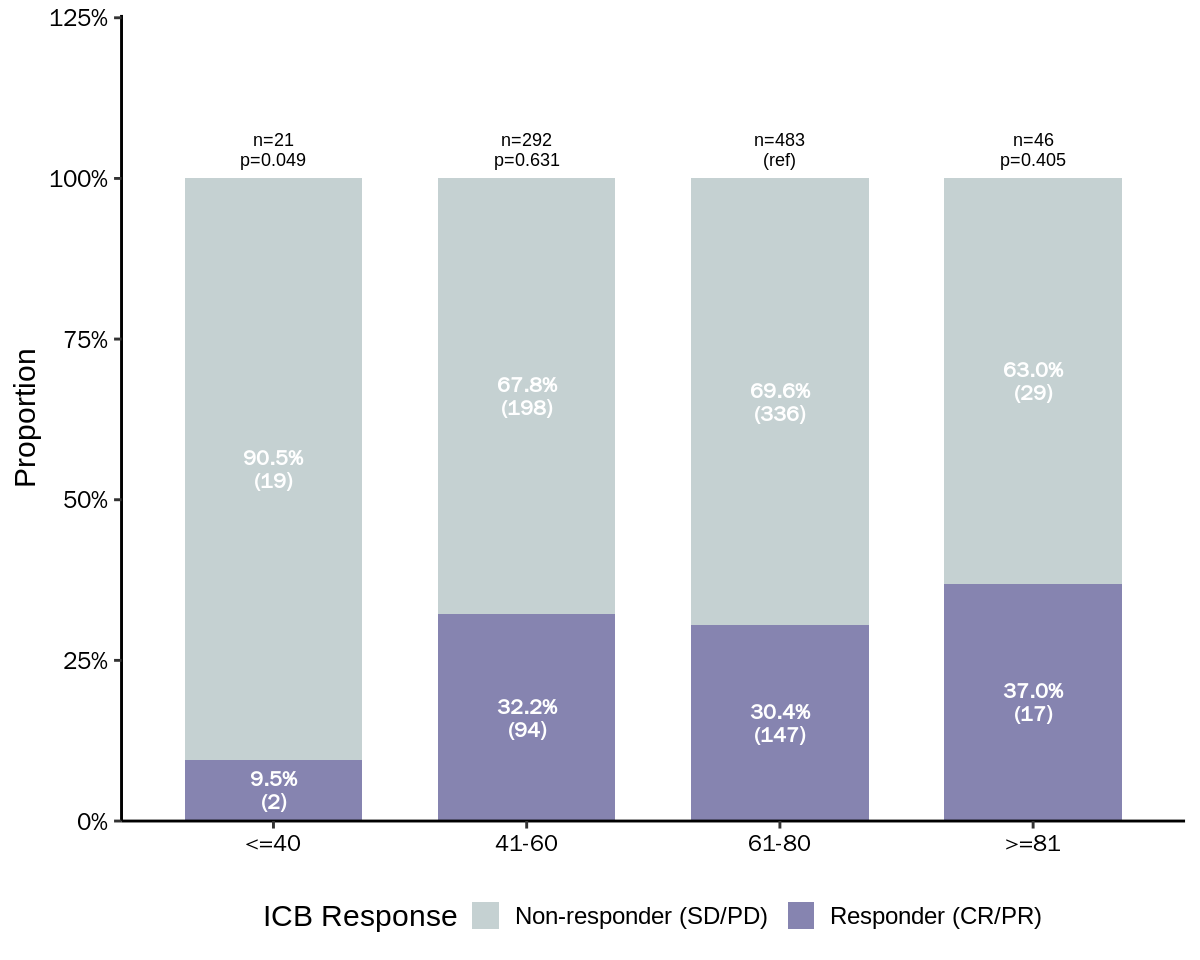

In [3]:
# Fisher exact test vs 61-80
age_groups <- levels(ICB_cohort_df$age_group)
ref_group <- "61-80"

fisher_pvals <- c()
for (g in setdiff(age_groups, ref_group)) {
  tab <- ICB_cohort_df %>% filter(age_group %in% c(g, ref_group), !is.na(response_NR)) %>%
    select(age_group, response_NR) %>% table()
  ft <- fisher.test(tab)
  fisher_pvals[g] <- ft$p.value
  message(sprintf("  %s vs %s: OR=%.3f [%.2f-%.2f], p=%.4f",
    g, ref_group, as.numeric(ft$estimate), ft$conf.int[1], ft$conf.int[2], ft$p.value))
}
fisher_pvals[ref_group] <- NA

# Bar plot with N and p-values
bar_data <- ICB_cohort_df %>% filter(!is.na(response_NR)) %>%
  group_by(age_group, response_NR) %>% summarise(n_patient = n(), .groups = "drop_last") %>%
  mutate(n_total = sum(n_patient), Proportion = n_patient / n_total) %>% ungroup()

anno_data <- bar_data %>% group_by(age_group) %>%
  summarise(n_total = unique(n_total), .groups = "drop") %>%
  mutate(
    p_value = fisher_pvals[as.character(age_group)],
    p_label = case_when(
      age_group == ref_group ~ paste0("n=", n_total, "\n(ref)"),
      p_value < 0.001 ~ paste0("n=", n_total, "\np=", sprintf("%.2e", p_value)),
      TRUE ~ paste0("n=", n_total, "\np=", sprintf("%.3f", p_value))))

options(repr.plot.width = 10, repr.plot.height = 8)
bar_data %>%
  ggplot(aes(x = age_group, y = Proportion, fill = response_NR)) +
  geom_col(width = 0.7) +
  geom_text(aes(label = paste0(percent(Proportion, 0.1), "\n(", n_patient, ")")),
    position = position_stack(vjust = 0.5), size = 4.5, color = "white",
    fontface = "bold", lineheight = 0.9) +
  geom_text(data = anno_data, aes(x = age_group, y = 1.02, label = p_label),
    inherit.aes = FALSE, size = 3.8, color = "black", vjust = 0, lineheight = 0.9) +
  scale_y_continuous(labels = percent, expand = expansion(mult = c(0, 0.12)), limits = c(0, 1.12)) +
  scale_fill_manual(values = c("N" = "#C5D1D2", "R" = "#8684B0"),
    labels = c("N" = "Non-responder (SD/PD)", "R" = "Responder (CR/PR)")) +
  xlab(NULL) + ylab("Proportion") + labs(fill = "ICB Response") +
  theme_classic(base_size = 18) +
  theme(legend.position = "bottom", axis.text = element_text(colour = "black"),
    axis.text.x = element_text(size = 14))

ggsave(file.path(figures, "Figures_raw", "ICB_Response_AgeGroup_BarPlot_v3.pdf"),
  device = "pdf", width = 10, height = 8, bg = "transparent")
message("Saved bar plot (N=", sum(!is.na(ICB_cohort_df$response_NR)), ")")

### 2. Sensitivity Analysis: Young-Age Cutoffs vs 61-80

# A tibble: 5 × 9
  cutoff n_young n_ref pct_R_young pct_R_ref    OR CI_lower CI_upper p_value
   <dbl>   <int> <int>       <dbl>     <dbl> <dbl>    <dbl>    <dbl>   <dbl>
1     40      21   483         9.5      30.4 0.241   0.0269    1.02   0.0486
2     42      25   483        12        30.4 0.312   0.0589    1.06   0.0693
3     45      37   483        18.9      30.4 0.534   0.193     1.28   0.190 
4     48      65   483        15.4      30.4 0.416   0.184     0.854  0.0125
5     50      90   483        20        30.4 0.572   0.310     1.01   0.0565


Saved sensitivity forest plot



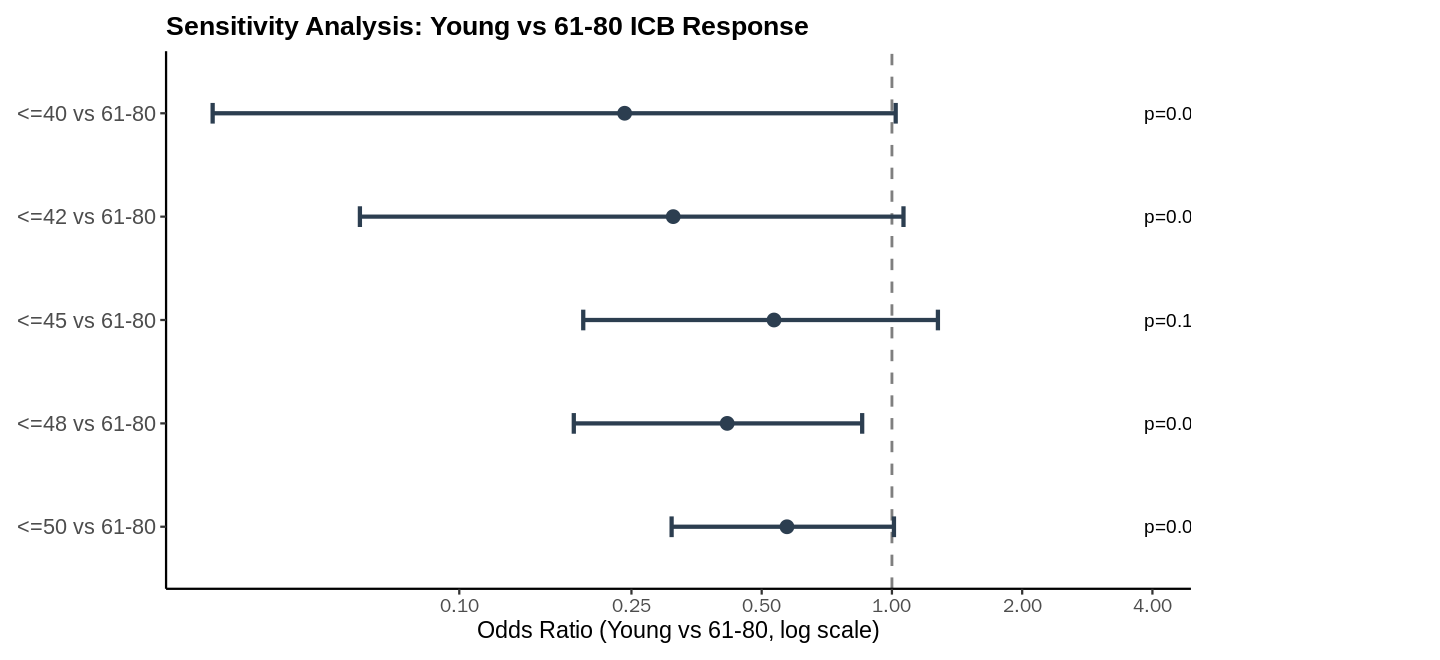

In [4]:
# ============================================================
# Sensitivity Analysis: young-age cutoffs vs 61-80 (Fisher)
# ============================================================
young_cutoffs <- c(40, 42, 45, 48, 50)
sensitivity_results <- list()

for (cutoff in young_cutoffs) {
  df_tmp <- ICB_cohort_df %>% filter(!is.na(response_NR)) %>%
    mutate(age_binary = case_when(
      age_yrs <= cutoff ~ "Young",
      age_yrs >= 61 & age_yrs <= 80 ~ "Ref_61_80",
      TRUE ~ NA_character_)) %>%
    filter(!is.na(age_binary))
  
  tab <- table(df_tmp$age_binary, df_tmp$response_NR)
  if (nrow(tab) < 2 || ncol(tab) < 2) next
  ft <- fisher.test(tab)
  
  sensitivity_results[[as.character(cutoff)]] <- tibble(
    cutoff       = cutoff,
    n_young      = sum(tab["Young", ]),
    n_ref        = sum(tab["Ref_61_80", ]),
    pct_R_young  = round(tab["Young", "R"] / sum(tab["Young", ]) * 100, 1),
    pct_R_ref    = round(tab["Ref_61_80", "R"] / sum(tab["Ref_61_80", ]) * 100, 1),
    OR           = as.numeric(ft$estimate),
    CI_lower     = ft$conf.int[1],
    CI_upper     = ft$conf.int[2],
    p_value      = ft$p.value)
}

sensitivity_df <- bind_rows(sensitivity_results)
print(sensitivity_df, width = Inf)

# ============================================================
# Forest plot: y-axis = "<=40 vs 61-80", p-values only, uniform color
# ============================================================
sensitivity_plot <- sensitivity_df %>%
  mutate(
    OR_plot       = ifelse(OR == 0 | is.infinite(OR) | is.na(OR), NA, OR),
    CI_lower_plot = ifelse(is.infinite(CI_lower) | is.na(CI_lower), NA, CI_lower),
    CI_upper_plot = ifelse(is.infinite(CI_upper) | is.na(CI_upper), NA, CI_upper),
    comparison    = paste0("<=", cutoff, " vs 61-80"),
    p_label       = ifelse(p_value < 0.001, sprintf("p=%.2e", p_value), sprintf("p=%.3f", p_value)))

x_max <- max(sensitivity_plot$CI_upper_plot, na.rm = TRUE)
x_max_plot <- ifelse(is.finite(x_max), x_max * 3, 5)

options(repr.plot.width = 12, repr.plot.height = 5.5)
ggplot(sensitivity_plot,
  aes(x = OR_plot, y = factor(comparison, levels = rev(comparison)))) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey50", linewidth = 0.8) +
  geom_point(size = 3.5, color = "#2C3E50") +
  geom_errorbarh(aes(xmin = CI_lower_plot, xmax = CI_upper_plot),
    height = 0.2, linewidth = 1.2, color = "#2C3E50") +
  geom_text(aes(x = x_max_plot, label = p_label),
    hjust = 0, size = 4, color = "black") +
  scale_x_log10(name = "Odds Ratio (Young vs 61-80, log scale)",
    breaks = c(0.1, 0.25, 0.5, 1, 2, 4)) +
  ylab(NULL) +
  theme_classic(base_size = 14) +
  theme(axis.text.y = element_text(size = 13),
    plot.title = element_text(size = 16, face = "bold"),
    plot.margin = margin(10, 150, 10, 10)) +
  ggtitle("Sensitivity Analysis: Young vs 61-80 ICB Response")

ggsave(file.path(figures, "Figures_raw", "ICB_Response_AgeCutoff_ForestPlot_v3.pdf"),
  device = "pdf", width = 12, height = 5.5, bg = "transparent")
message("Saved sensitivity forest plot")